## CD

PDF saved to: CD_Results_2x2.pdf


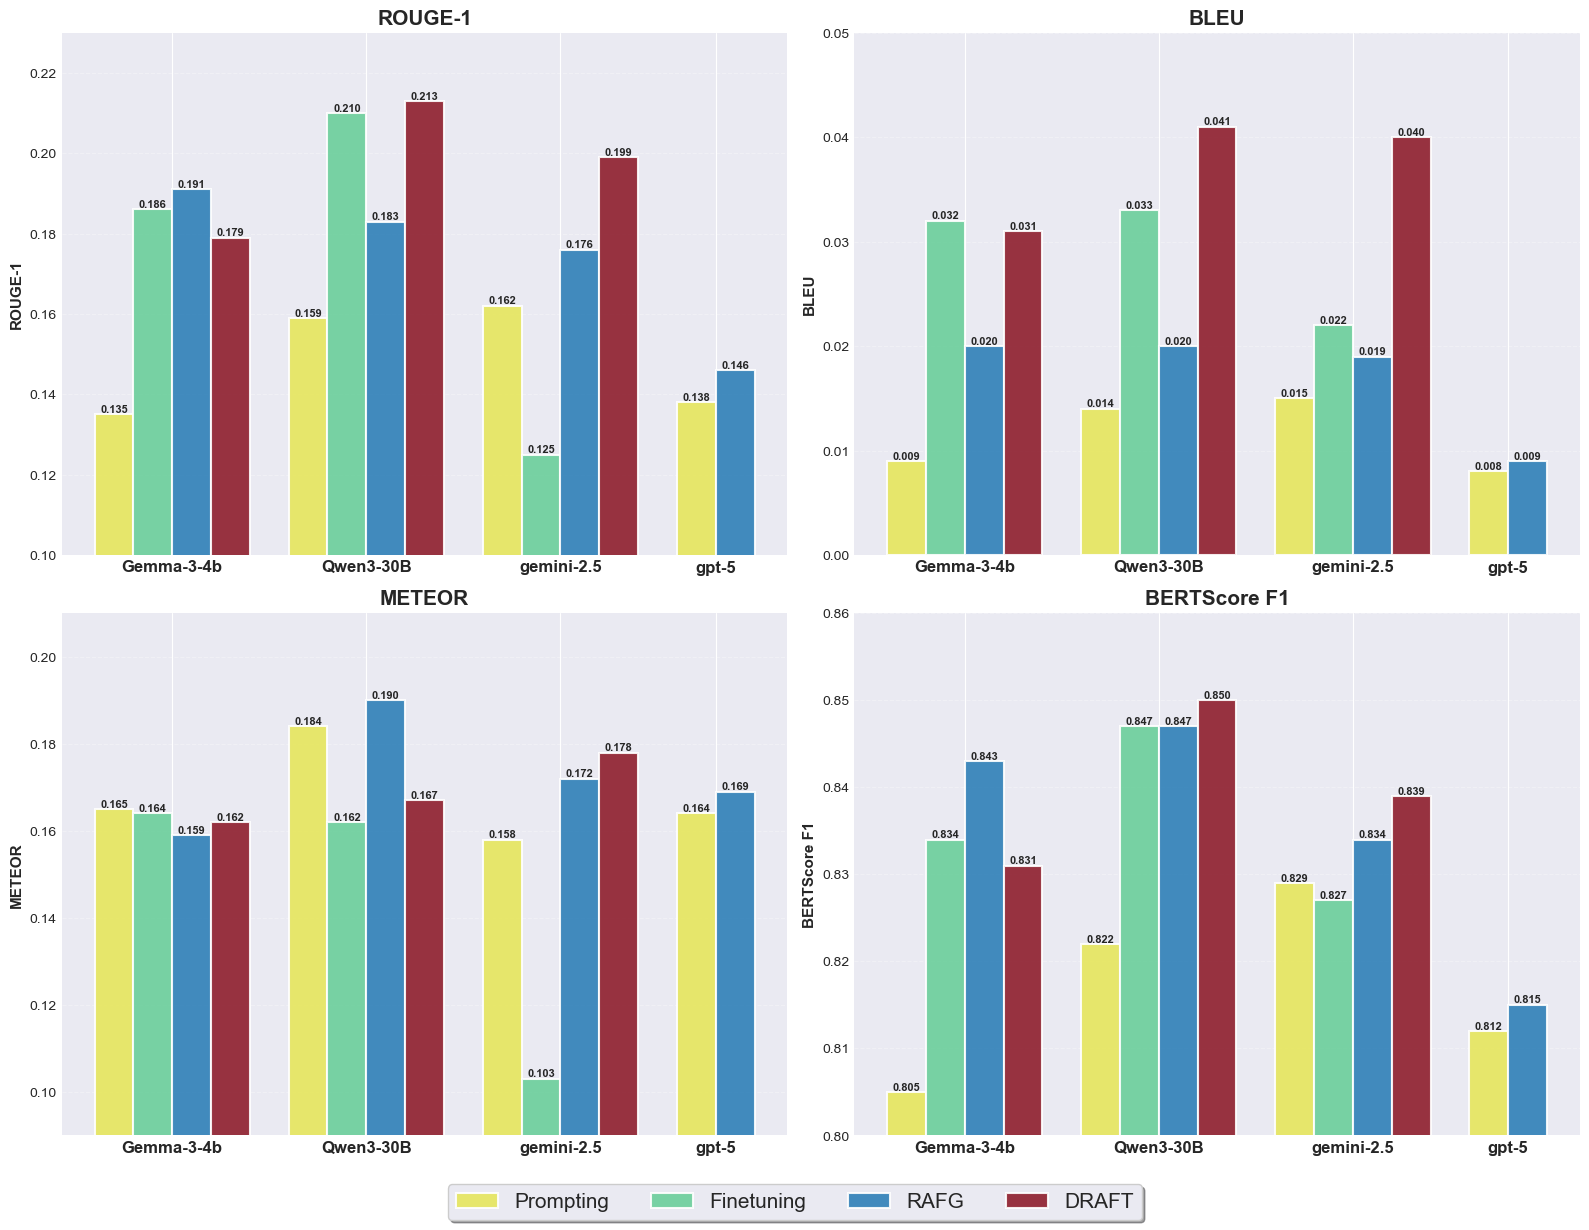

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# CD Test Data
cd_data = {
    'BERTScore F1': {
        'Gemma-3-4b': {'Prompting': 0.805, 'Finetuning': 0.834, 'RAFG': 0.843, 'DRAFT': 0.831},
        'Qwen3-30B': {'Prompting': 0.822, 'Finetuning': 0.847, 'RAFG': 0.847, 'DRAFT': 0.850},
        'gemini-2.5': {'Prompting': 0.829, 'Finetuning': 0.827, 'RAFG': 0.834, 'DRAFT': 0.839},
        'gpt-5': {'Prompting': 0.812, 'RAFG': 0.815}
    },
    'ROUGE-1': {
        'Gemma-3-4b': {'Prompting': 0.135, 'Finetuning': 0.186, 'RAFG': 0.191, 'DRAFT': 0.179},
        'Qwen3-30B': {'Prompting': 0.159, 'Finetuning': 0.210, 'RAFG': 0.183, 'DRAFT': 0.213},
        'gemini-2.5': {'Prompting': 0.162, 'Finetuning': 0.125, 'RAFG': 0.176, 'DRAFT': 0.199},
        'gpt-5': {'Prompting': 0.138, 'RAFG': 0.146}
    },
    'BLEU': {
        'Gemma-3-4b': {'Prompting': 0.009, 'Finetuning': 0.032, 'RAFG': 0.020, 'DRAFT': 0.031},
        'Qwen3-30B': {'Prompting': 0.014, 'Finetuning': 0.033, 'RAFG': 0.020, 'DRAFT': 0.041},
        'gemini-2.5': {'Prompting': 0.015, 'Finetuning': 0.022, 'RAFG': 0.019, 'DRAFT': 0.040},
        'gpt-5': {'Prompting': 0.008, 'RAFG': 0.009}
    },
    'METEOR': {
        'Gemma-3-4b': {'Prompting': 0.165, 'Finetuning': 0.164, 'RAFG': 0.159, 'DRAFT': 0.162},
        'Qwen3-30B': {'Prompting': 0.184, 'Finetuning': 0.162, 'RAFG': 0.190, 'DRAFT': 0.167},
        'gemini-2.5': {'Prompting': 0.158, 'Finetuning': 0.103, 'RAFG': 0.172, 'DRAFT': 0.178},
        'gpt-5': {'Prompting': 0.164, 'RAFG': 0.169}
    }
}

# Color scheme
colors = {
    'Prompting':  '#E6E65C',
    'Finetuning': '#6BCF9B',
    'RAFG':       '#2F80B8',
    'DRAFT':      '#8E1E2D'
}

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()
plot_titles = ['ROUGE-1', 'BLEU', 'METEOR', 'BERTScore F1']

# Helper function to create bar chart
def create_bar_chart(ax, metric_data, title, colors, ylim):
    models = list(metric_data.keys())
    width = 0.2
    approaches = ['Prompting', 'Finetuning', 'RAFG', 'DRAFT']
    
    other_models = [m for m in models if m != 'gpt-5']
    x = np.arange(len(other_models))
    
    # Plot bars for each approach
    for i, approach in enumerate(approaches):
        values = [metric_data[model].get(approach, 0) for model in other_models]
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, values, width, label=approach, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Plot gpt-5 separately
    gpt5_x = len(other_models) - 0.2
    gpt5_approaches = [a for a in approaches if a in metric_data['gpt-5']]
    for i, approach in enumerate(gpt5_approaches):
        offset = (i - 0.5) * width
        value = metric_data['gpt-5'][approach]
        bars = ax.bar(gpt5_x + offset, value, width, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., value,
                   f'{value:.3f}',
                   ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Customize plot
    # ax.set_xlabel('Models', fontsize=11, fontweight='bold')
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xticks(list(range(len(other_models))) + [len(other_models) - 0.2])
    ax.set_xticklabels(other_models + ['gpt-5'], fontsize=12, fontweight='bold')
    ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Create each subplot
ylim_ranges = {
    'BERTScore F1': (0.80, 0.86),
    'ROUGE-1': (0.10, 0.23),
    'BLEU': (0, 0.050),
    'METEOR': (0.09, 0.21)
}

for idx, (ax, title) in enumerate(zip(axes_flat, plot_titles)):
    create_bar_chart(ax, cd_data[title], title, colors, ylim_ranges[title])

# Add shared legend at bottom
handles, labels = [], []
for approach in ['Prompting', 'Finetuning', 'RAFG', 'DRAFT']:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors[approach], 
                                 edgecolor='white', linewidth=1.5, alpha=0.9))
    labels.append(approach)

fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15, 
           bbox_to_anchor=(0.5, -0.03), frameon=True, fancybox=True, shadow=True)

# Adjust layout
plt.tight_layout(rect=[0, 0.02, 1, 1])

# Save as PDF
output_path = Path('CD_Results_2x2.pdf')
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"PDF saved to: {output_path}")

plt.show()

## TB

PDF saved to: TB_Results_2x2.pdf


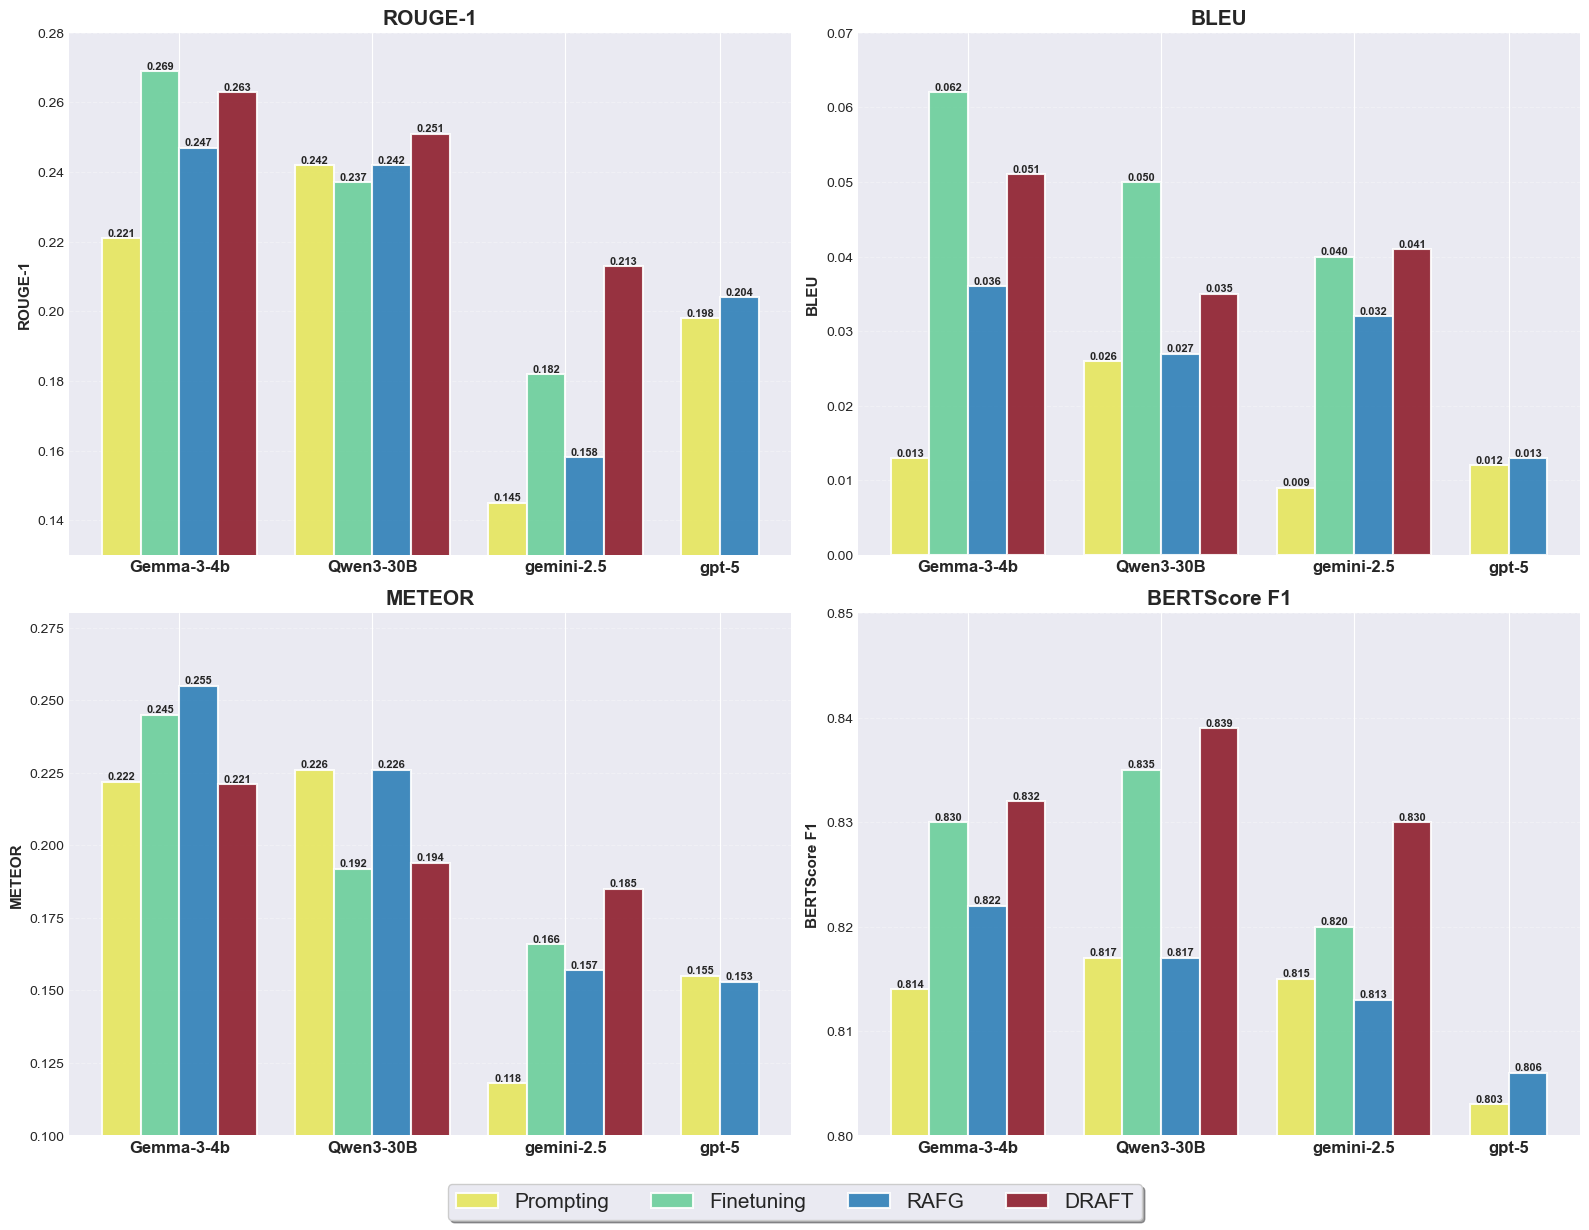

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# TB Test Data
tb_data = {
    'BERTScore F1': {
        'Gemma-3-4b': {'Prompting': 0.814, 'Finetuning': 0.830, 'RAFG': 0.822, 'DRAFT': 0.832},
        'Qwen3-30B': {'Prompting': 0.817, 'Finetuning': 0.835, 'RAFG': 0.817, 'DRAFT': 0.839},
        'gemini-2.5': {'Prompting': 0.815, 'Finetuning': 0.820, 'RAFG': 0.813, 'DRAFT': 0.830},
        'gpt-5': {'Prompting': 0.803, 'RAFG': 0.806}
    },
    'ROUGE-1': {
        'Gemma-3-4b': {'Prompting': 0.221, 'Finetuning': 0.269, 'RAFG': 0.247, 'DRAFT': 0.263},
        'Qwen3-30B': {'Prompting': 0.242, 'Finetuning': 0.237, 'RAFG': 0.242, 'DRAFT': 0.251},
        'gemini-2.5': {'Prompting': 0.145, 'Finetuning': 0.182, 'RAFG': 0.158, 'DRAFT': 0.213},
        'gpt-5': {'Prompting': 0.198, 'RAFG': 0.204}
    },
    'BLEU': {
        'Gemma-3-4b': {'Prompting': 0.013, 'Finetuning': 0.062, 'RAFG': 0.036, 'DRAFT': 0.051},
        'Qwen3-30B': {'Prompting': 0.026, 'Finetuning': 0.050, 'RAFG': 0.027, 'DRAFT': 0.035},
        'gemini-2.5': {'Prompting': 0.009, 'Finetuning': 0.040, 'RAFG': 0.032, 'DRAFT': 0.041},
        'gpt-5': {'Prompting': 0.012, 'RAFG': 0.013}
    },
    'METEOR': {
        'Gemma-3-4b': {'Prompting': 0.222, 'Finetuning': 0.245, 'RAFG': 0.255, 'DRAFT': 0.221},
        'Qwen3-30B': {'Prompting': 0.226, 'Finetuning': 0.192, 'RAFG': 0.226, 'DRAFT': 0.194},
        'gemini-2.5': {'Prompting': 0.118, 'Finetuning': 0.166, 'RAFG': 0.157, 'DRAFT': 0.185},
        'gpt-5': {'Prompting': 0.155, 'RAFG': 0.153}
    }
}

# Color scheme
colors = {
    'Prompting':  '#E6E65C',
    'Finetuning': '#6BCF9B',
    'RAFG':       '#2F80B8',
    'DRAFT':      '#8E1E2D'
}

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()
plot_titles = ['ROUGE-1', 'BLEU', 'METEOR', 'BERTScore F1']

# Helper function to create bar chart
def create_bar_chart(ax, metric_data, title, colors, ylim):
    models = list(metric_data.keys())
    width = 0.2
    approaches = ['Prompting', 'Finetuning', 'RAFG', 'DRAFT']
    
    other_models = [m for m in models if m != 'gpt-5']
    x = np.arange(len(other_models))
    
    # Plot bars for each approach
    for i, approach in enumerate(approaches):
        values = [metric_data[model].get(approach, 0) for model in other_models]
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, values, width, label=approach, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Plot gpt-5 separately
    gpt5_x = len(other_models) - 0.2
    gpt5_approaches = [a for a in approaches if a in metric_data['gpt-5']]
    for i, approach in enumerate(gpt5_approaches):
        offset = (i - 0.5) * width
        value = metric_data['gpt-5'][approach]
        bars = ax.bar(gpt5_x + offset, value, width, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., value,
                   f'{value:.3f}',
                   ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Customize plot
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xticks(list(range(len(other_models))) + [len(other_models) - 0.2])
    ax.set_xticklabels(other_models + ['gpt-5'], fontsize=12, fontweight='bold')
    ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Create each subplot
ylim_ranges = {
    'BERTScore F1': (0.80, 0.85),
    'ROUGE-1': (0.13, 0.28),
    'BLEU': (0, 0.070),
    'METEOR': (0.10, 0.28)
}

for idx, (ax, title) in enumerate(zip(axes_flat, plot_titles)):
    create_bar_chart(ax, tb_data[title], title, colors, ylim_ranges[title])

# Add shared legend at bottom
handles, labels = [], []
for approach in ['Prompting', 'Finetuning', 'RAFG', 'DRAFT']:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors[approach], 
                                 edgecolor='white', linewidth=1.5, alpha=0.9))
    labels.append(approach)

fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15, 
           bbox_to_anchor=(0.5, -0.03), frameon=True, fancybox=True, shadow=True)

# Adjust layout
plt.tight_layout(rect=[0, 0.02, 1, 1])

# Save as PDF
output_path = Path('TB_Results_2x2.pdf')
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"PDF saved to: {output_path}")

plt.show()

## Loss Plots

PDF saved to: Validation_Loss_2x2.pdf


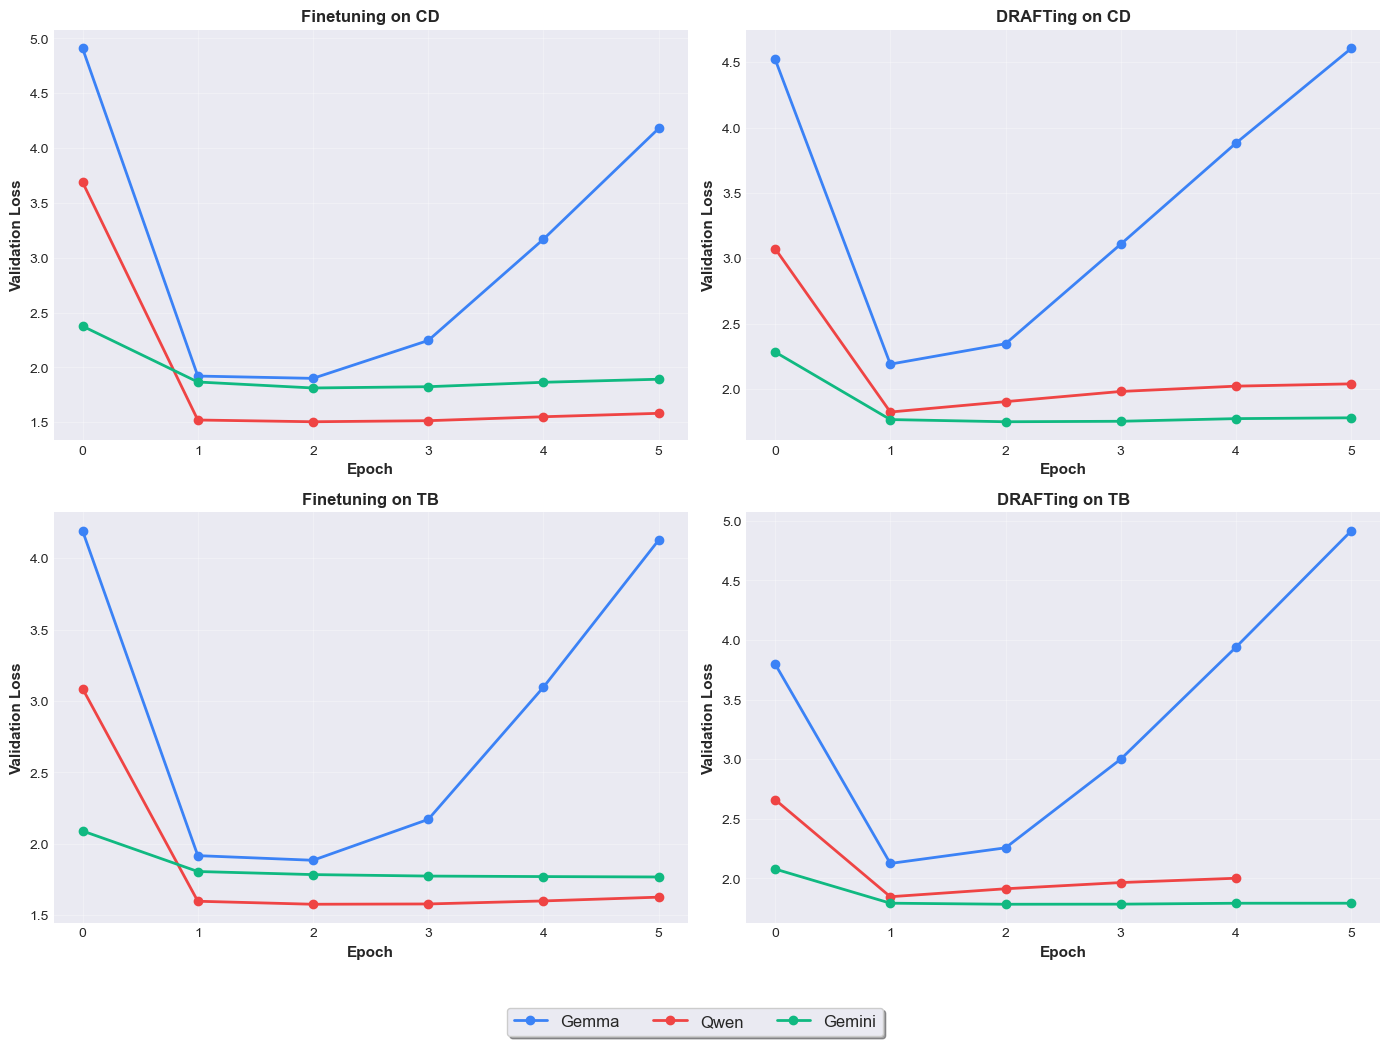

In [80]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Define directories
finetune_output_dir = Path('../../Finetune/Output')
draft_output_dir = Path('../../DRAFT/Output')

# Color scheme
colors = {'Gemma': '#3b82f6', 'Qwen': '#ef4444', 'Gemini': '#10b981'}

# Define model files
models = {
    'Gemma': 'loss_log_gemma-3-4b-it',
    'Qwen': 'loss_log_qwen3-30b-a3b-instruct-2507',
    'Gemini': 'loss_log_gemini-2.5-flash'
}

# Load data function
def load_validation_data(output_dir, file_prefix, task):
    validation_data = {}
    for model_name, file_base in models.items():
        filename = f'{file_base}_{task}.jsonl'
        file_path = output_dir / filename
        epochs = []
        val_losses = []
        
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                epochs.append(data['epoch'])
                val_losses.append(data['val_loss'])
        
        validation_data[model_name] = {
            'epochs': epochs,
            'val_losses': val_losses
        }
    return validation_data

# Load all data
ft_cd = load_validation_data(finetune_output_dir, 'loss_log', 'CD')
draft_cd = load_validation_data(draft_output_dir, 'loss_log', 'CD')
ft_tb = load_validation_data(finetune_output_dir, 'loss_log', 'TB')
draft_tb = load_validation_data(draft_output_dir, 'loss_log', 'TB')

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Finetuning CD (top-left)
ax = axes[0, 0]
for model_name, data in ft_cd.items():
    ax.plot(data['epochs'], data['val_losses'], 
            marker='o', linewidth=2, color=colors[model_name], markersize=6)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
ax.set_title('Finetuning on CD', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 2: Drafting CD (top-right)
ax = axes[0, 1]
for model_name, data in draft_cd.items():
    ax.plot(data['epochs'], data['val_losses'], 
            marker='o', linewidth=2, color=colors[model_name], markersize=6)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
ax.set_title('DRAFTing on CD', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Finetuning TB (bottom-left)
ax = axes[1, 0]
for model_name, data in ft_tb.items():
    ax.plot(data['epochs'], data['val_losses'], 
            marker='o', linewidth=2, color=colors[model_name], markersize=6)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
ax.set_title('Finetuning on TB', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: Drafting TB (bottom-right)
ax = axes[1, 1]
for model_name, data in draft_tb.items():
    ax.plot(data['epochs'], data['val_losses'], 
            marker='o', label=model_name, linewidth=2, color=colors[model_name], markersize=6)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
ax.set_title('DRAFTing on TB', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add shared legend at bottom
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12, 
           bbox_to_anchor=(0.5, -0.05), frameon=True, fancybox=True, shadow=True)

# Adjust layout to make room for shared legend
plt.tight_layout(rect=[0, 0.02, 1, 1])

# Save as PDF
output_path = Path('Validation_Loss_2x2.pdf')
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"PDF saved to: {output_path}")

plt.show()

## Effeciency Plots

In [3]:
import json

# Read test.jsonl and extract token counts
test_jsonl_path = "../../Data/ADR-data/test.jsonl"

token_body_list = []
token_decision_list = []

with open(test_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        token_body_list.append(record.get('tokenBody', 0))
        token_decision_list.append(record.get('tokenDecision', 0))

# Calculate averages
avg_token_body = sum(token_body_list) / len(token_body_list) if token_body_list else 0
avg_token_decision = sum(token_decision_list) / len(token_decision_list) if token_decision_list else 0

print(f"Total records: {len(token_body_list)}")
print(f"\nAverage tokens in Body: {avg_token_body:.2f}")
print(f"Average tokens in Decision: {avg_token_decision:.2f}")
print(f"Average combined (Body + Decision): {avg_token_body + avg_token_decision:.2f}")


Total records: 870

Average tokens in Body: 274.62
Average tokens in Decision: 72.86
Average combined (Body + Decision): 347.48


PDF saved to: Output_Tokens_Chart_Combined.pdf


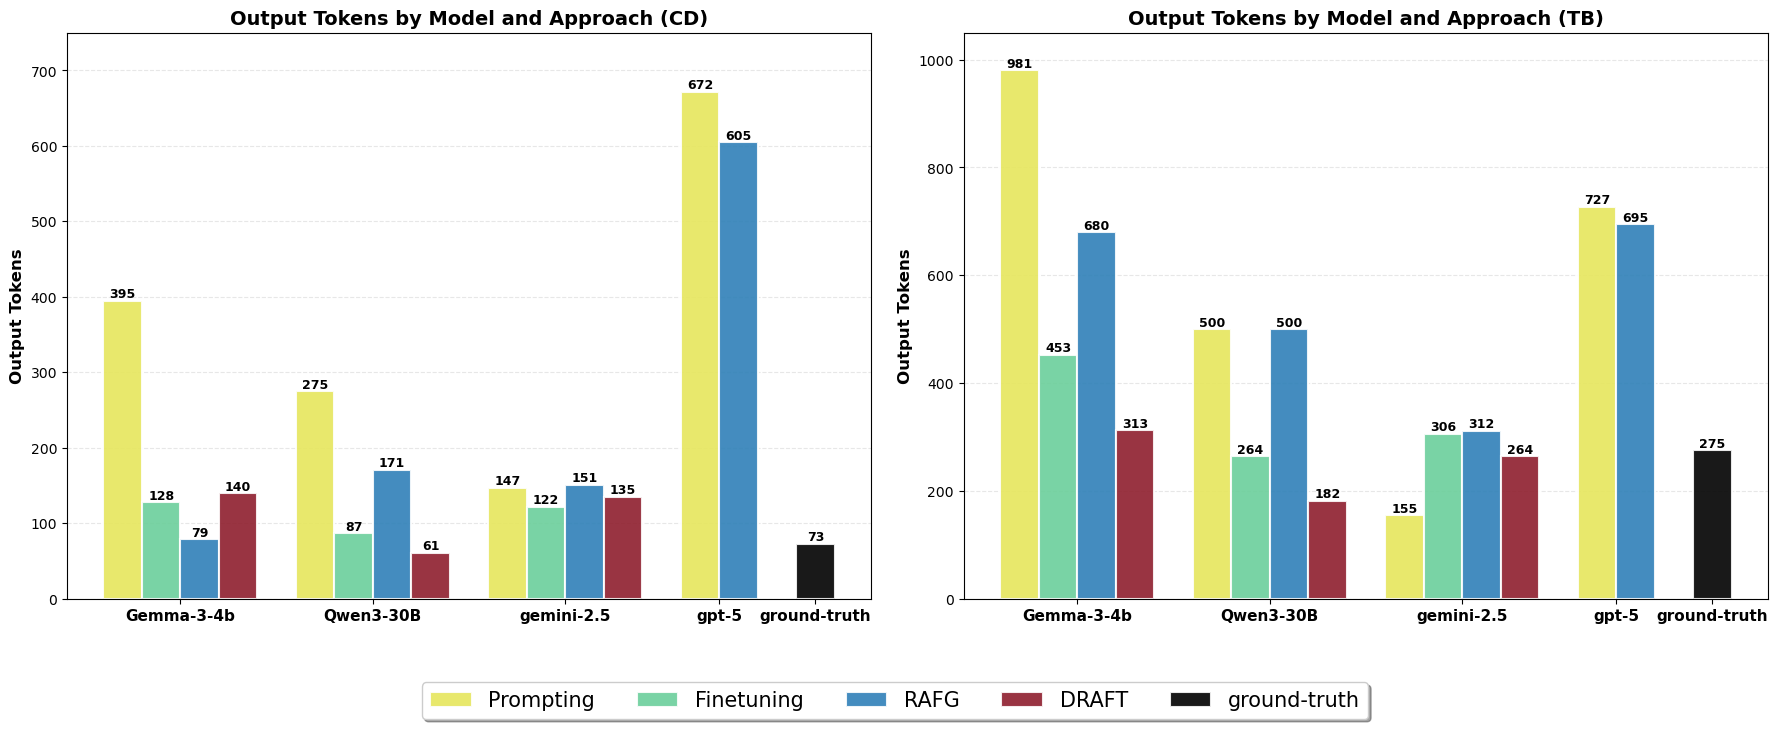

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Output Tokens Data - CD
output_tokens_data_cd = {
    'Gemma-3-4b': {'Prompting': 395, 'Finetuning': 128, 'RAFG': 79, 'DRAFT': 140},
    'Qwen3-30B': {'Prompting': 275, 'Finetuning': 87, 'RAFG': 171, 'DRAFT': 61},
    'gemini-2.5': {'Prompting': 147, 'Finetuning': 122, 'RAFG': 151, 'DRAFT': 135},
    'gpt-5': {'Prompting': 672, 'RAFG': 605}
}

# Output Tokens Data - TB
output_tokens_data_tb = {
    'Gemma-3-4b': {'Prompting': 981, 'Finetuning': 453, 'RAFG': 680, 'DRAFT': 313},
    'Qwen3-30B': {'Prompting': 500, 'Finetuning': 264, 'RAFG': 500, 'DRAFT': 182},
    'gemini-2.5': {'Prompting': 155, 'Finetuning': 306, 'RAFG': 312, 'DRAFT': 264},
    'gpt-5': {'Prompting': 727, 'RAFG': 695}
}

# Color scheme
colors = {
    'Prompting':  '#E6E65C',
    'Finetuning': '#6BCF9B',
    'RAFG':       '#2F80B8',
    'DRAFT':      '#8E1E2D',
    'ground-truth': '#000000'
}

# Create 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Helper function to create bar chart
def create_output_tokens_chart(ax, output_tokens_data, title, ylim, gtruth_value):
    models = ['Gemma-3-4b', 'Qwen3-30B', 'gemini-2.5']
    gpt5_data = output_tokens_data.pop('gpt-5')
    width = 0.2
    approaches = ['Prompting', 'Finetuning', 'RAFG', 'DRAFT']
    
    x = np.arange(len(models))
    
    # Plot bars for each approach
    for i, approach in enumerate(approaches):
        values = [output_tokens_data[model].get(approach, 0) for model in models]
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, values, width, label=approach, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot gpt-5 separately
    gpt5_x = len(models) - 0.2
    gpt5_approaches = ['Prompting', 'RAFG']
    for i, approach in enumerate(gpt5_approaches):
        offset = (i - 0.5) * width
        value = gpt5_data[approach]
        bars = ax.bar(gpt5_x + offset, value, width, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., value,
                   f'{int(value)}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add ground-truth bar (single bar to the side)
    ground_truth_x = len(models) + 0.3
    bars = ax.bar(ground_truth_x, gtruth_value, width, label='ground-truth', 
                  color=colors['ground-truth'], edgecolor='white', linewidth=1.5, alpha=0.9)
    
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., gtruth_value,
               f'{int(gtruth_value)}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Customize plot
    ax.set_ylabel('Output Tokens', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(list(range(len(models))) + [len(models) - 0.2, ground_truth_x])
    ax.set_xticklabels(models + ['gpt-5', 'ground-truth'], fontsize=11, fontweight='bold')
    ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Plot CD (left)
cd_data = output_tokens_data_cd.copy()
create_output_tokens_chart(axes[0], cd_data, 'Output Tokens by Model and Approach (CD)', (0, 750), 73)

# Plot TB (right)
tb_data = output_tokens_data_tb.copy()
create_output_tokens_chart(axes[1], tb_data, 'Output Tokens by Model and Approach (TB)', (0, 1050), 275)

# Add shared legend at bottom
handles, labels = [], []
for approach in ['Prompting', 'Finetuning', 'RAFG', 'DRAFT', 'ground-truth']:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors[approach], 
                                 edgecolor='white', linewidth=1.5, alpha=0.9))
    labels.append(approach)

fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=15, 
           bbox_to_anchor=(0.5, -0.05), frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])

# Save as PDF
output_path = Path('Output_Tokens_Chart_Combined.pdf')
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"PDF saved to: {output_path}")

plt.show()

PDF saved to: Response_Time_Chart_Combined.pdf


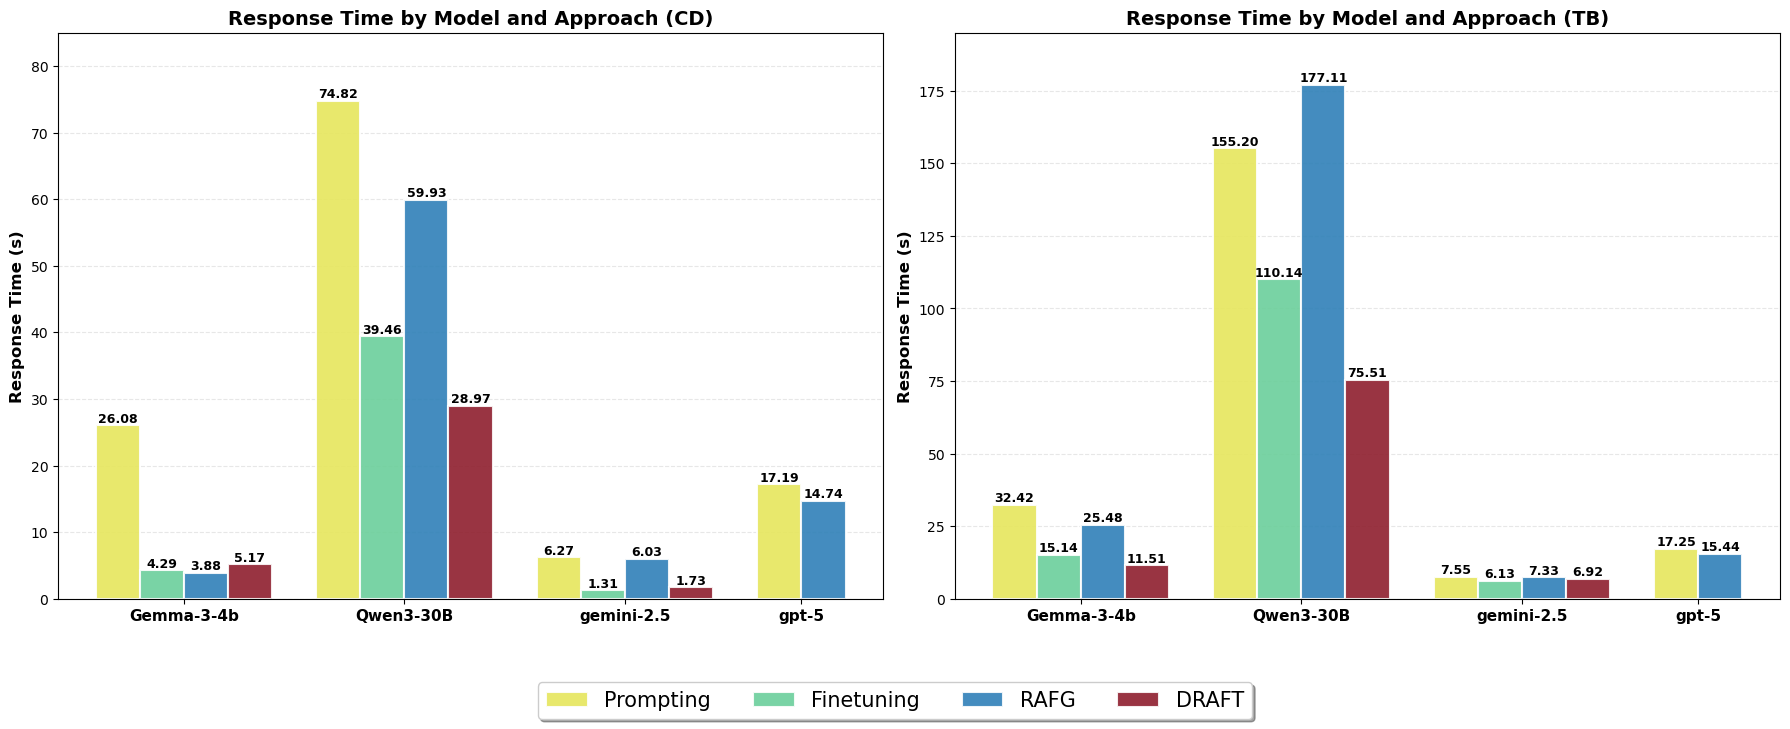

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Response Time Data - CD
response_time_data_cd = {
    'Gemma-3-4b': {'Prompting': 26.08, 'Finetuning': 4.29, 'RAFG': 3.88, 'DRAFT': 5.17},
    'Qwen3-30B': {'Prompting': 74.82, 'Finetuning': 39.46, 'RAFG': 59.93, 'DRAFT': 28.97},
    'gemini-2.5': {'Prompting': 6.27, 'Finetuning': 1.31, 'RAFG': 6.03, 'DRAFT': 1.73},
    'gpt-5': {'Prompting': 17.19, 'RAFG': 14.74}
}

# Response Time Data - TB
response_time_data_tb = {
    'Gemma-3-4b': {'Prompting': 32.42, 'Finetuning': 15.14, 'RAFG': 25.48, 'DRAFT': 11.51},
    'Qwen3-30B': {'Prompting': 155.20, 'Finetuning': 110.14, 'RAFG': 177.11, 'DRAFT': 75.51},
    'gemini-2.5': {'Prompting': 7.55, 'Finetuning': 6.13, 'RAFG': 7.33, 'DRAFT': 6.92},
    'gpt-5': {'Prompting': 17.25, 'RAFG': 15.44}
}

# Color scheme
colors = {
    'Prompting':  '#E6E65C',
    'Finetuning': '#6BCF9B',
    'RAFG':       '#2F80B8',
    'DRAFT':      '#8E1E2D'
}

# Create 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Helper function to create response time bar chart
def create_response_time_chart(ax, response_time_data, title, ylim):
    models = ['Gemma-3-4b', 'Qwen3-30B', 'gemini-2.5']
    gpt5_data = response_time_data.pop('gpt-5')
    width = 0.2
    approaches = ['Prompting', 'Finetuning', 'RAFG', 'DRAFT']
    
    x = np.arange(len(models))
    
    # Plot bars for each approach
    for i, approach in enumerate(approaches):
        values = [response_time_data[model].get(approach, 0) for model in models]
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, values, width, label=approach, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot gpt-5 separately
    gpt5_x = len(models) - 0.2
    gpt5_approaches = ['Prompting', 'RAFG']
    for i, approach in enumerate(gpt5_approaches):
        offset = (i - 0.5) * width
        value = gpt5_data[approach]
        bars = ax.bar(gpt5_x + offset, value, width, color=colors[approach], 
                      edgecolor='white', linewidth=1.5, alpha=0.9)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., value,
                   f'{value:.2f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Customize plot
    ax.set_ylabel('Response Time (s)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(list(range(len(models))) + [len(models) - 0.2])
    ax.set_xticklabels(models + ['gpt-5'], fontsize=11, fontweight='bold')
    ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Plot CD (left)
cd_data = response_time_data_cd.copy()
create_response_time_chart(axes[0], cd_data, 'Response Time by Model and Approach (CD)', (0, 85))

# Plot TB (right)
tb_data = response_time_data_tb.copy()
create_response_time_chart(axes[1], tb_data, 'Response Time by Model and Approach (TB)', (0, 195))

# Add shared legend at bottom
handles, labels = [], []
for approach in ['Prompting', 'Finetuning', 'RAFG', 'DRAFT']:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors[approach], 
                                 edgecolor='white', linewidth=1.5, alpha=0.9))
    labels.append(approach)

fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15, 
           bbox_to_anchor=(0.5, -0.05), frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])

# Save as PDF
output_path = Path('Response_Time_Chart_Combined.pdf')
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"PDF saved to: {output_path}")

plt.show()